In [1]:
import csv

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 36

2026-08-15 22:06:41.225047: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-15 22:06:41.225465: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-15 22:06:41.228105: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-15 22:06:41.235865: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-08-15 22:06:41.248522: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been 

# Specify each path

In [2]:
# Specify data paths
dataset = 'new_pose_data.csv'
model_save_path = 'keypoint_classifier.keras'
tflite_save_path = 'keypoint_classifier.tflite'

# Set number of classes

In [3]:
# Change training classes if necessary
NUM_CLASSES = 12

# Dataset reading

In [4]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (12 * 3) + 1)))

In [5]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11], dtype=int32), array([399, 402, 378, 407, 561, 398, 398, 282, 628, 467, 349, 474]))


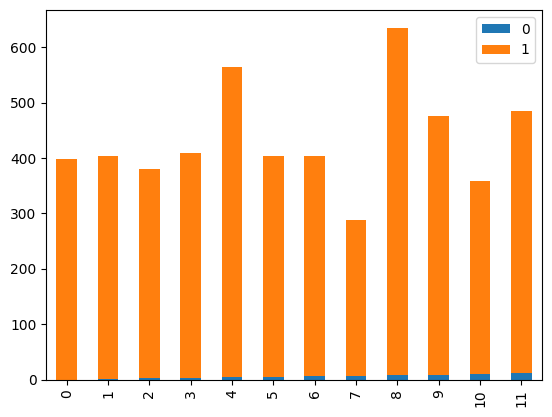

In [7]:
# Classes count
counts = np.unique(y_dataset, return_counts=True)
df = pd.DataFrame(counts)
df.T.plot(kind="bar", stacked=True)
print(counts)

# Model building

In [8]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((36,)),  # 12 puntos * 3 coordenadas (X, Y, Z)
    tf.keras.layers.Dropout(0.0),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.0),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.0),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')  # Salida con softmax según el número de clases
])


In [9]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout (Dropout)               │ (None, 36)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 12)             │           204 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,972 (11.61 KB)

 Trainable params: 2,972 (11.61 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Model checkpoint callback
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False, save_best_only=True)
# Callback for early stopping
es_callback = tf.keras.callbacks.EarlyStopping(patience=50, verbose=1)

In [11]:
# Model compilation
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (12 * 3) + 1)))

# Model training

In [13]:
model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000
 1/61 ━━━━━━━━━━━━━━━━━━━━ 49s 824ms/step - accuracy: 0.1250 - loss: 2.4575
Epoch 1: val_loss improved from inf to 2.28355, saving model to keypoint_classifier.keras
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1347 - loss: 2.4416 - val_accuracy: 0.2652 - val_loss: 2.2836
Epoch 2/1000
 1/61 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2500 - loss: 2.2723
Epoch 2: val_loss improved from 2.28355 to 1.95915, saving model to keypoint_classifier.keras
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2459 - loss: 2.2306 - val_accuracy: 0.2885 - val_loss: 1.9591
Epoch 3/1000
 1/61 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2969 - loss: 2.0073
Epoch 3: val_loss improved from 1.95915 to 1.53009, saving model to keypoint_classifier.keras
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3379 - loss: 1.8734 - val_accuracy: 0.5443 - val_loss: 1.5301
Epoch 4/1000
 1/61 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5469 - loss: 1.4787
Epoch 4: val_loss improved 

In [14]:
# Loading the saved model
model = tf.keras.models.load_model(model_save_path)

In [15]:
# Model evaluation
# TODO Test on loaded model
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=64)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 632us/step - accuracy: 0.9987 - loss: 0.0025  


In [16]:
# Inference test
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
[2.08813603e-19 3.77220535e-28 1.20530334e-04 1.94984922e-27
 3.51833775e-12 9.99297380e-01 5.01828087e-27 4.08590539e-09
 8.25909760e-31 5.82025270e-04 3.97100692e-15 5.24875983e-16]
5


# Confusion matrix

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 527us/step


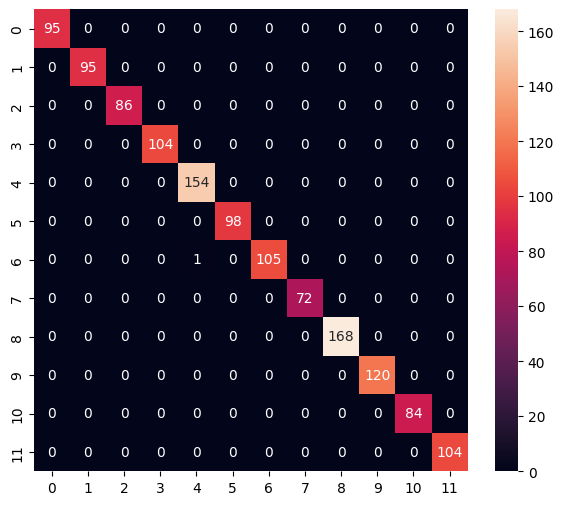

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        95
           1       1.00      1.00      1.00        95
           2       1.00      1.00      1.00        86
           3       1.00      1.00      1.00       104
           4       0.99      1.00      1.00       154
           5       1.00      1.00      1.00        98
           6       1.00      0.99      1.00       106
           7       1.00      1.00      1.00        72
           8       1.00      1.00      1.00       168
           9       1.00      1.00      1.00       120
          10       1.00      1.00      1.00        84
          11       1.00      1.00      1.00       104

    accuracy                           1.00      1286
   macro avg       1.00      1.00      1.00      1286
weighted avg       1.00      1.00      1.00      1286



In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# Convert to model for Tensorflow-Lite

In [18]:
# Save as a model dedicated to inference
model.save(model_save_path, include_optimizer=False)
           
# Ruta del modelo .keras
keras_model_path = 'keypoint_classifier.keras'  # Ajusta esta ruta

# Cargar el modelo .keras
model = tf.keras.models.load_model(keras_model_path)

In [19]:
# Transform model (quantization)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: /tmp/tmpms5qcbe5/assets


INFO:tensorflow:Assets written to: /tmp/tmpms5qcbe5/assets


Saved artifact at '/tmp/tmpms5qcbe5'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 36), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 12), dtype=tf.float32, name=None)
Captures:
  135779664979600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135779664976912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135779664981136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135779664978640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135779664979216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135779664978448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135779664981904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135779664982672: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1786842638.684230 1686929 tf_tfl_flatbuffer_helpers.cc:392] Ignored output_format.
W0000 00:00:1786842638.684258 1686929 tf_tfl_flatbuffer_helpers.cc:395] Ignored drop_control_dependency.
2026-08-15 22:10:38.684877: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpms5qcbe5
2026-08-15 22:10:38.685406: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-08-15 22:10:38.685417: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpms5qcbe5
2026-08-15 22:10:38.688711: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:388] MLIR V1 optimization pass is not enabled
2026-08-15 22:10:38.689547: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-08-15 22:10:38.715297: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpms5qcbe5
2026-08-15 22:10:38.721269: I tensorflow/cc/saved_model/loader.cc

8640

## Inference test

In [20]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [21]:
# Get I / O tensor
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [22]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [23]:
%%time
# Inference implementation
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: user 425 μs, sys: 0 ns, total: 425 μs
Wall time: 330 μs


In [24]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[4.8729138e-19 3.8899466e-28 2.8719447e-04 2.8529365e-27 6.9388831e-12
 9.9885225e-01 5.8473286e-27 4.7175766e-09 1.8994258e-30 8.6056563e-04
 7.1998478e-15 5.7695459e-16]
5


## Download model

In [25]:
!zip -r model.zip keypoint_classifier  

	zip warning: name not matched: keypoint_classifier

zip error: Nothing to do! (try: zip -r model.zip . -i keypoint_classifier)




---


# ❗️Hyperparameters Tuning

In [26]:
%load_ext tensorboard
from tensorboard.plugins.hparams import api as hp

In [27]:
# Init parameters to tune
HP_NUM_UNITS_1 = hp.HParam('num_units_1', hp.Discrete([16, 32, 64]))
HP_NUM_UNITS_2 = hp.HParam('num_units_2', hp.Discrete([8, 16, 32]))
HP_NUM_UNITS_3 = hp.HParam('num_units_3', hp.Discrete([8, 16, 32]))
HP_DROPOUT = hp.HParam('dropout', hp.RealInterval(0.0, 0.2))
HP_OPTIMIZER = hp.HParam('optimizer', hp.Discrete(['adam', 'sgd']))

METRIC_ACCURACY = 'accuracy'

In [28]:
with tf.summary.create_file_writer('logs/hparam_tuning').as_default():
  hp.hparams_config(
    hparams=[HP_NUM_UNITS_1,HP_NUM_UNITS_2,HP_NUM_UNITS_3, HP_DROPOUT, HP_OPTIMIZER],
    metrics=[hp.Metric(METRIC_ACCURACY, display_name='Accuracy')],
  )

In [29]:
# Model checkpoint callback
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False, save_best_only=True)
# Callback for early stopping
es_callback = tf.keras.callbacks.EarlyStopping(patience=15, verbose=1)

In [30]:
def train_test_model(hparams):

  model = tf.keras.models.Sequential([
    tf.keras.layers.Input((12 * 3, )),
    tf.keras.layers.Dropout(hparams[HP_DROPOUT]),
    tf.keras.layers.Dense(hparams[HP_NUM_UNITS_1], activation='relu'),
    tf.keras.layers.Dropout(hparams[HP_DROPOUT]),
    tf.keras.layers.Dense(hparams[HP_NUM_UNITS_2], activation='relu'),
    tf.keras.layers.Dropout(hparams[HP_DROPOUT]),
    tf.keras.layers.Dense(hparams[HP_NUM_UNITS_3], activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])
  
  model.compile(
    optimizer=hparams[HP_OPTIMIZER],
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
  
  cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False, save_best_only=True)

  model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[
               cp_callback,
               es_callback,
               ]
  ) 

  # Load model with best accuracy
  model = tf.keras.models.load_model(model_save_path)

  _, accuracy = model.evaluate(X_test, y_test)
  return accuracy

def run(run_dir, hparams):
  with tf.summary.create_file_writer(run_dir).as_default():
    hp.hparams(hparams)  # record the values used in this trial
    accuracy = train_test_model(hparams)
    tf.summary.scalar(METRIC_ACCURACY, accuracy, step=1)

In [ ]:
session_num = 0

for num_units_1 in HP_NUM_UNITS_1.domain.values:
  for num_units_2 in HP_NUM_UNITS_2.domain.values:
    for num_units_3 in HP_NUM_UNITS_3.domain.values:
      for dropout_rate in np.arange(HP_DROPOUT.domain.min_value, HP_DROPOUT.domain.max_value, 0.1):
        for optimizer in HP_OPTIMIZER.domain.values:
          hparams = {
              HP_NUM_UNITS_1: num_units_1,
              HP_NUM_UNITS_2: num_units_2,
              HP_NUM_UNITS_3: num_units_3,
              HP_DROPOUT: dropout_rate,
              HP_OPTIMIZER: optimizer,
          }
          run_name = "run-%d" % session_num
          print('--- Starting trial: %s' % run_name)
          print({h.name: hparams[h] for h in hparams})
          run('logs/hparam_tuning/' + run_name, hparams)
          session_num += 1

--- Starting trial: run-0
{'num_units_1': 16, 'num_units_2': 8, 'num_units_3': 8, 'dropout': 0.0, 'optimizer': 'adam'}
Epoch 1/50
 1/61 ━━━━━━━━━━━━━━━━━━━━ 33s 552ms/step - accuracy: 0.0469 - loss: 2.5738
Epoch 1: val_loss improved from inf to 2.44363, saving model to keypoint_classifier.keras
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0991 - loss: 2.5081 - val_accuracy: 0.1198 - val_loss: 2.4436
Epoch 2/50
 1/61 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1406 - loss: 2.4540
Epoch 2: val_loss improved from 2.44363 to 2.36516, saving model to keypoint_classifier.keras
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1110 - loss: 2.4362 - val_accuracy: 0.1275 - val_loss: 2.3652
Epoch 3/50
 1/61 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0938 - loss: 2.4030
Epoch 3: val_loss improved from 2.36516 to 2.24763, saving model to keypoint_classifier.keras
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1330 - loss: 2.3566 - val_accuracy: 0.1851 - val_loss: 2.2476
E

In [ ]:
# !ATTENTION! Works only in Colab
%tensorboard --logdir logs/hparam_tuning

In [ ]:
!rm -rf logs